# Netflix Movies & TV Shows - Data Analysis

## 1. Introduction

Netflix is one of the world’s largest entertainment platforms, offering a diverse collection of movies and TV shows across multiple genres and countries. Through Exploratory Data Analysis (EDA), this project examines Netflix’s content trends related to genres, release years, countries of production, and content ratings to uncover patterns that support data-driven decision making.

## 2. Importing Libraries and Data Set

In [1]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style = "whitegrid")

In [2]:
#loading data set and checking first 10 vakues

df = pd.read_csv("netflix_titles.csv")
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


## 3. Data Understanding and Cleaning

In [3]:
#checking basic info of data set

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
#checking for null values

df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
#repacing null values(NaN) with 0

column_with_nan = ["director", "cast", "country", "date_added", "rating", "duration"]
df[column_with_nan] = df[column_with_nan].replace(np.nan, 0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8807 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8807 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## 4. Expository Data Analysis (EDA)

### 4.1. Movies vs TV Shows

Q. How many total movies vs TV shows are in the dataset?

In [6]:
contents = df["type"].value_counts()

movies = contents["Movie"]
tv_shows = contents["TV Show"]

print(f"Number of Movies in the dataset: {movies}")
print(f"Number of TV Shows in the dataset: {tv_shows}")

Number of Movies in the dataset: 6131
Number of TV Shows in the dataset: 2676


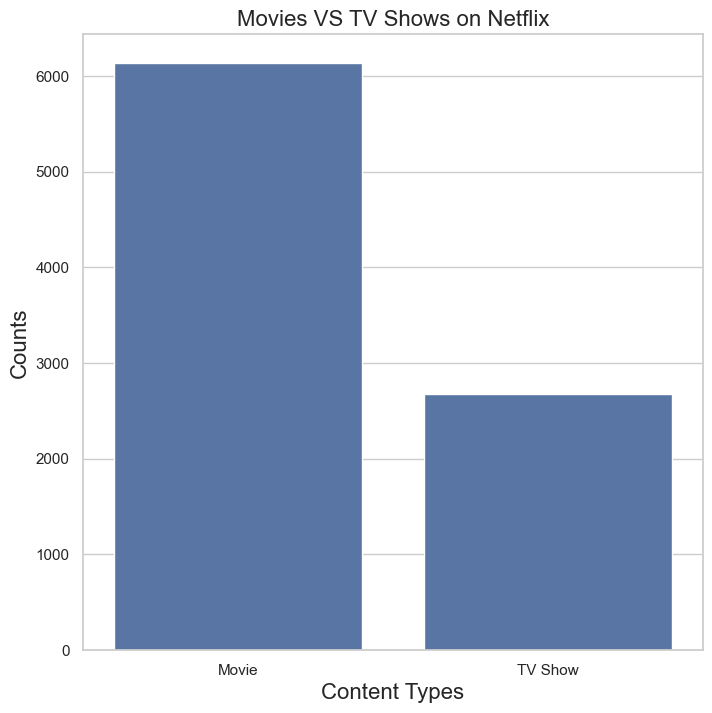

In [7]:
plt.figure(figsize = (8,8))
sns.barplot(x=contents.index,y=contents.values)
plt.title(f"Movies VS TV Shows on Netflix", fontsize = 16)
plt.xlabel(f"Content Types", fontsize = 16)
plt.ylabel(f"Counts", fontsize = 16)
plt.show()

The dataset contains both Movies and TV Shows, with Movies being more prevalent, showing Netflix’s emphasis on film content.

### 4.2. Top Countries Producing Netflix Content

Q. Which are the top 10 countries producing Netflix content?

In [8]:
df['country'].value_counts()

country
United States                                             2818
India                                                      972
0                                                          831
United Kingdom                                             419
Japan                                                      245
                                                          ... 
Germany, Canada, United States                               1
Denmark, United Kingdom, South Africa, Sweden, Belgium       1
Serbia, South Korea, Slovenia                                1
United Kingdom, Spain, Belgium                               1
South Africa, United States, Japan                           1
Name: count, Length: 749, dtype: int64

In [9]:
top10_countries = (df[df["country"] != 0]["country"].str.split(", ").explode().value_counts().head(10))

print(f"Top 10 countries producing Netflix content are: \n {top10_countries}")

Top 10 countries producing Netflix content are: 
 country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


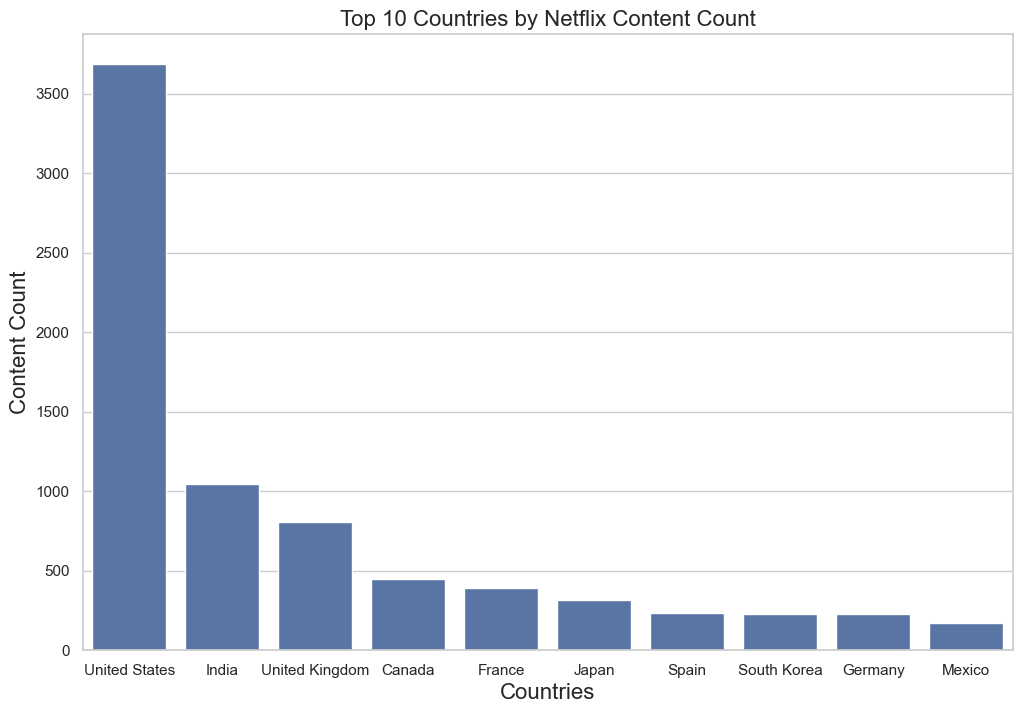

In [10]:
plt.figure(figsize=(12,8))
sns.barplot(x=top10_countries.index, y=top10_countries.values)
plt.title(f"Top 10 Countries by Netflix Content Count", fontsize = 16)
plt.xlabel(f"Countries", fontsize = 16)
plt.ylabel(f"Content Count", fontsize = 16)
plt.show()

The top 10 countries producing Netflix content are identified, highlighting that a few countries dominate content creation, with the United States leading production.

### 4.3. Most Common Genre

Q. What is the most common genre on Netflix?

In [11]:
common_genre = (df[df["listed_in"] != 0]["listed_in"].str.split(", ").explode().value_counts().head(10))

print(f"Most common genre on Netflix are: \n{common_genre}")

Most common genre on Netflix are: 
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


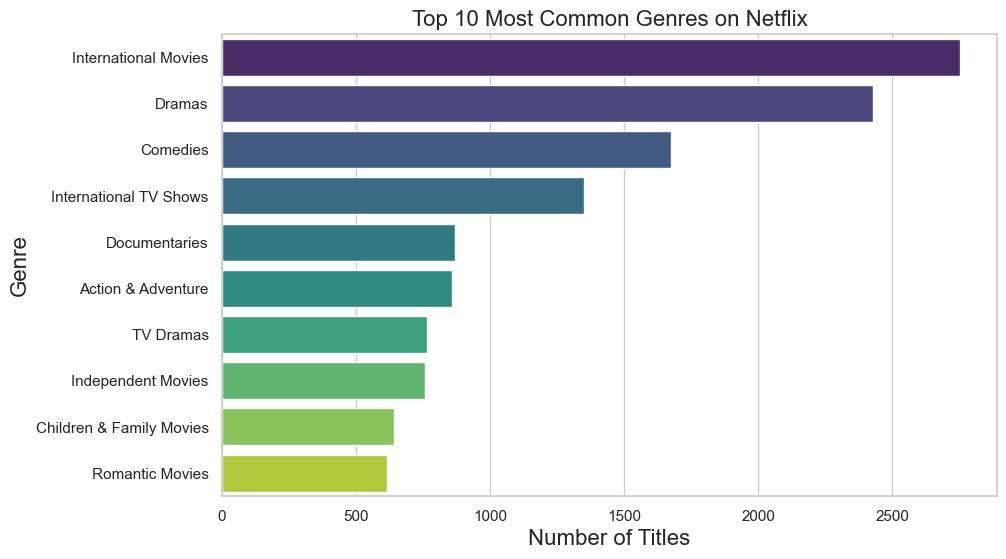

In [12]:
genre_df = common_genre.reset_index()
genre_df.columns = ["Genre", "Count"]

plt.figure(figsize=(10,6))
sns.barplot(data=genre_df, x="Count", y="Genre", hue="Genre", palette="viridis")
plt.xlabel(f"Number of Titles", fontsize = 16)
plt.ylabel(f"Genre", fontsize = 16)
plt.title(f"Top 10 Most Common Genres on Netflix", fontsize = 16)
plt.show()

Frequency analysis of genres shows that International Movies and Dramas are the most common genres, indicating Netflix’s strong focus on globally appealing film content.

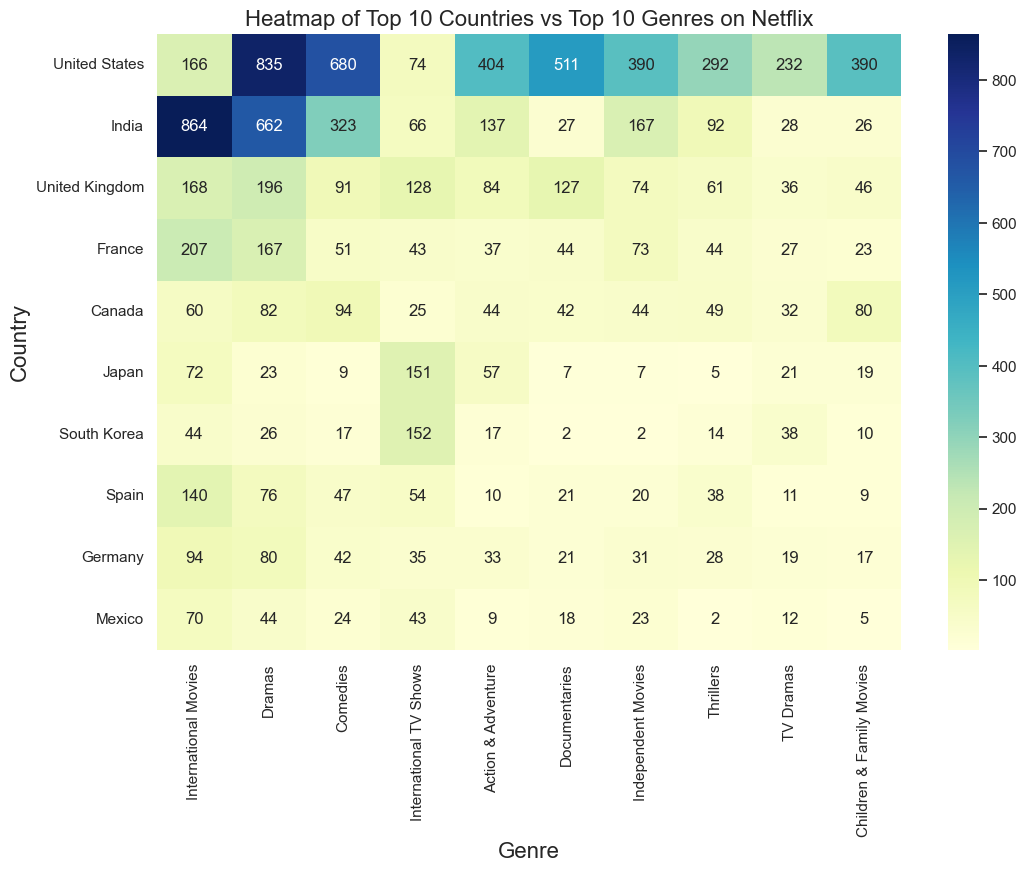

In [13]:
# remove invalid entries
df_clean = df[(df["country"] != 0) & (df["listed_in"] != 0)]

# Expand multiple countries
df_expanded = df_clean.assign(country=df_clean["country"].str.split(", ")).explode("country")

# Expand multiple genres
df_expanded = df_expanded.assign(genre=df_expanded["listed_in"].str.split(", ")).explode("genre")

country_genre_counts = pd.crosstab(df_expanded["country"], df_expanded["genre"])

# Keep top 10 countries and top 10 genres for readability
top_countries = country_genre_counts.sum(axis=1).sort_values(ascending=False).head(10).index
top_genres = country_genre_counts.sum(axis=0).sort_values(ascending=False).head(10).index

country_genre_counts_top = country_genre_counts.loc[top_countries, top_genres]

plt.figure(figsize=(12,8))
sns.heatmap(country_genre_counts_top, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Heatmap of Top 10 Countries vs Top 10 Genres on Netflix", fontsize = 16)
plt.xlabel("Genre", fontsize = 16)
plt.ylabel("Country", fontsize = 16)
plt.show()

The heatmap reveals how Netflix content is distributed across top genres and countries. For example, the United States leads in multiple genres, while other countries produce content in fewer categories, highlighting regional content specialization.

### 4.4. Highest Number Of Releases

Q. Which years saw the highest number of releases?

In [14]:
df['release_year'].value_counts().head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

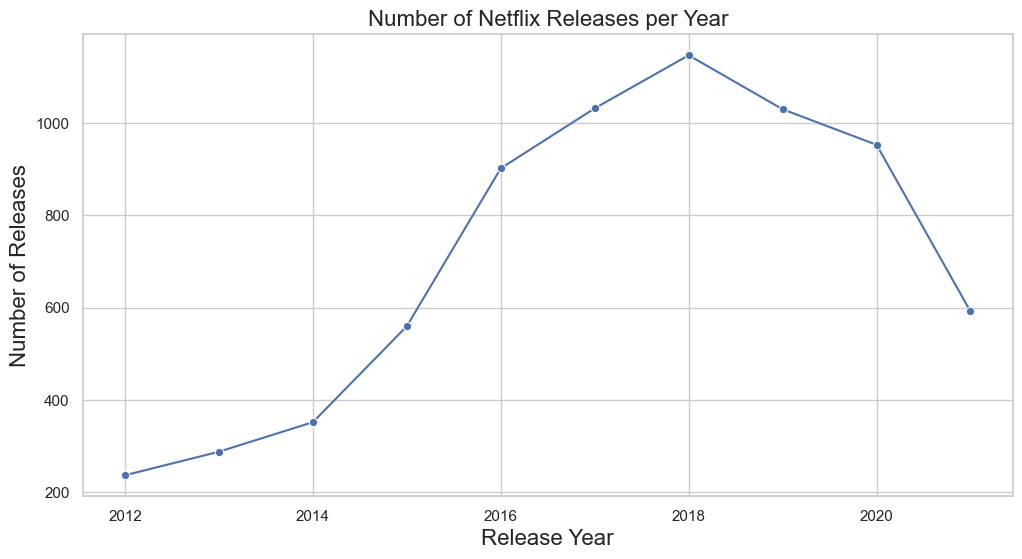

In [15]:
year_counts = df['release_year'].value_counts().head(10).sort_index()

plt.figure(figsize=(12,6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')
plt.xlabel(f"Release Year", fontsize = 16)
plt.ylabel(f"Number of Releases", fontsize = 16)
plt.title(f"Number of Netflix Releases per Year", fontsize = 16)
plt.show()

The analysis of release years shows that Netflix content production peaked in 2018 with 1,147 releases, followed closely by 2017 and 2019, highlighting consistent growth in content production over recent years.

### 4.5. Content Ratings Distribution.

Q. What is the distribution of content ratings?

In [16]:
df["rating"].value_counts

<bound method IndexOpsMixin.value_counts of 0       PG-13
1       TV-MA
2       TV-MA
3       TV-MA
4       TV-MA
        ...  
8802        R
8803    TV-Y7
8804        R
8805       PG
8806    TV-14
Name: rating, Length: 8807, dtype: object>

In [17]:
rating_distribution = df[df["rating"] != 0]["rating"].value_counts()

print(f"Distribution of ratings are: \n {rating_distribution}")

Distribution of ratings are: 
 rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


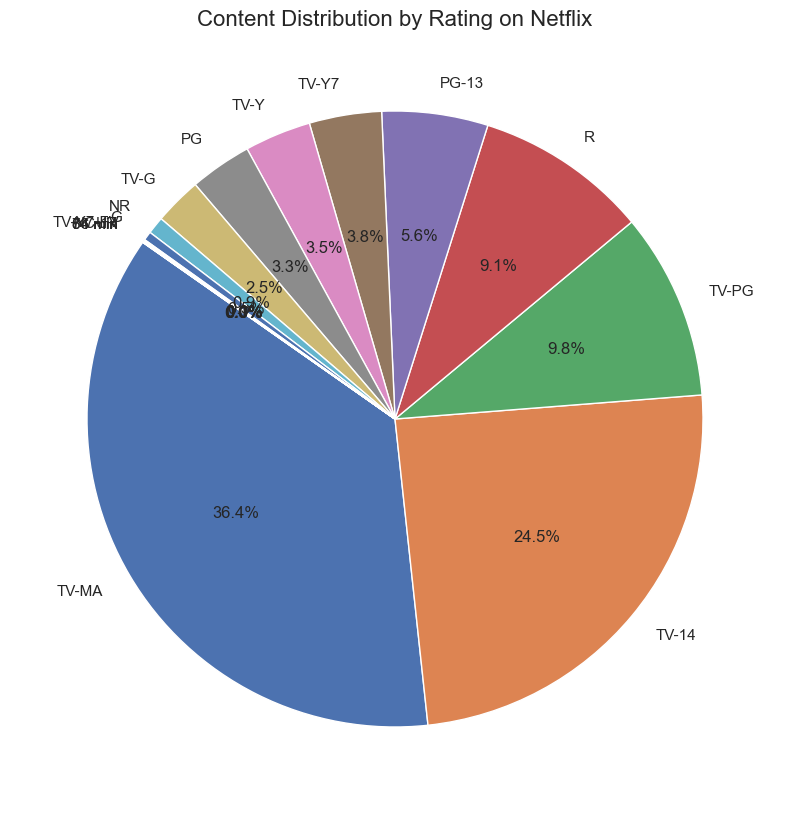

In [18]:
plt.figure(figsize=(10,10))
plt.pie(rating_distribution.values, labels=rating_distribution.index, autopct="%1.1f%%", startangle=145)
plt.title(f"Content Distribution by Rating on Netflix", fontsize = 16)
plt.show()

After removing invalid rating entries, the distribution shows that Netflix content is predominantly targeted toward mature and teenage audiences, with TV-MA and TV-14 being the most common ratings.

### 4.6. Directors Having Most Titles.

Q. Which directors have the most titles on Netflix?

In [19]:
top_directors = (df[df["director"] != 0]["director"].str.split(", ").explode().value_counts().head(10))

print(f"The directors having most titles on Netflix are: \n{top_directors}")

The directors having most titles on Netflix are: 
director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64


The analysis reveals that Rajiv Chilaka leads in the number of titles on Netflix, followed by Jan Suter and Raúl Campos, while several well-known directors such as Martin Scorsese also appear among the top contributors, indicating a mix of high-volume and renowned filmmakers on the platform.

## 5. Key Insights

1. Movies dominate Netflix compared to TV Shows, showing a focus on film content.
2. International Movies and Dramas are the most common genres, appealing to a global audience.
3. The United States produces the most content, followed by India and the UK.
4. Content releases peaked in 2018, reflecting high production and platform growth.
5. Most titles are rated TV-MA and TV-14, targeting mature and teenage audiences.
6. A few directors contribute many titles, indicating high-volume content specialization

## 6. References

1. Dataset Source:

   Netflix Movies and TV Shows Dataset, Kaggle: [ https://www.kaggle.com/datasets/vikasukani/diabetes-data-set ]

3. Python Libraries Used:

   a. Numpy
   b. Pandas
   c. Matplotlib
   d. Seaborn